In [1]:
from TARFlow import TARFlow
from tarflow_train import TrainConfig, build_model, Trainer
from tarflow_sample import SampleConfig, Sampler, load_model
from data import get_fmnist_loaders

import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
from collections import Counter

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec

In [2]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__}  |  device: {DEVICE}')

# Consistent figure style throughout
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#0f0f0f',
    'text.color':       '#e8e8e8',
    'axes.labelcolor':  '#e8e8e8',
    'xtick.color':      '#888888',
    'ytick.color':      '#888888',
    'axes.edgecolor':   '#333333',
    'grid.color':       '#222222',
    'font.family':      'monospace',
})

PyTorch 2.9.1+cpu  |  device: cpu


In [3]:
CLASS_NAMES = [
    'T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal',  'Shirt',   'Sneaker',  'Bag',   'Ankle boot'
]

cfg = TrainConfig(
    data_dir         = './data',
    output_dir       = './runs_fmnist',   # separate from MNIST runs

    img_size         = 16,
    channel_size     = 1,
    patch_size       = 4,

    channels         = 128,
    blocks           = 4,
    layers_per_block = 4,
    nvp              = True,
    unconditional    = False,

    epochs           = 50,
    batch_size       = 256,
    lr               = 1e-4,
    weight_decay     = 1e-4,
    grad_clip        = 1.0,

    noise_std        = 0.05,
    noise_type       = 'gaussian',
    drop_label       = 0.1,

    log_freq         = 200,
    resume           = '',
)

train_loader, val_loader = get_fmnist_loaders(cfg)

print(f'Training batches : {len(train_loader)}')
print(f'Val batches      : {len(val_loader)}')
print(f'Classes          : {CLASS_NAMES}')

Training batches : 234
Val batches      : 40
Classes          : ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


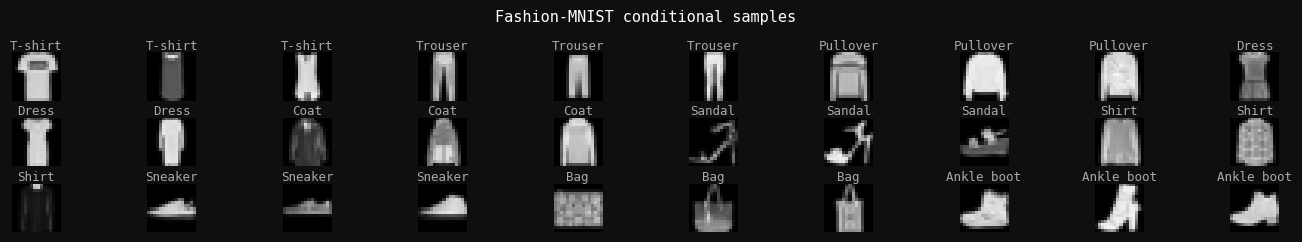

In [4]:
def show_grid(images, titles=None, nrow=10, figsize=(14, 2.2), suptitle=None, cmap='gray'):
    """
    Display a grid of (N, C, H, W) image tensors.
    Handles both [-1,1] normalised and [0,1] images.
    """
    imgs = images.cpu().float()
    # Map [-1,1] → [0,1] if needed
    if imgs.min() < -0.01:
        imgs = (imgs + 1) / 2
    imgs = imgs.clamp(0, 1)

    n    = len(imgs)
    ncol = nrow
    nrows = (n + ncol - 1) // ncol

    fig, axes = plt.subplots(nrows, ncol, figsize=figsize)
    fig.patch.set_facecolor('#0f0f0f')
    axes = np.array(axes).reshape(-1) if n > 1 else [axes]

    for i, ax in enumerate(axes):
        ax.axis('off')
        if i < n:
            img = imgs[i]
            if img.shape[0] == 1:
                ax.imshow(img[0].numpy(), cmap=cmap, vmin=0, vmax=1)
            else:
                ax.imshow(img.permute(1, 2, 0).numpy())
            if titles is not None and i < len(titles):
                ax.set_title(str(titles[i]), color='#aaaaaa', fontsize=9, pad=2)

    if suptitle:
        fig.suptitle(suptitle, color='#ffffff', fontsize=11, y=1.03)
    plt.tight_layout(pad=0.3)
    plt.show()


# Pick 3 examples per class → 30 images total
samples_per_class = 3
class_samples, class_labels = [], []
dataset = train_loader.dataset

for digit in range(10):
    indices = (dataset.targets == digit).nonzero(as_tuple=True)[0][:samples_per_class]
    for idx in indices:
        img, lbl = dataset[idx.item()]
        class_samples.append(img)
        class_labels.append(lbl)

class_samples = torch.stack(class_samples)

show_grid(
    class_samples,
    titles = [CLASS_NAMES[l] for l in class_labels],
    nrow   = 10,
    suptitle = 'Fashion-MNIST conditional samples',
)

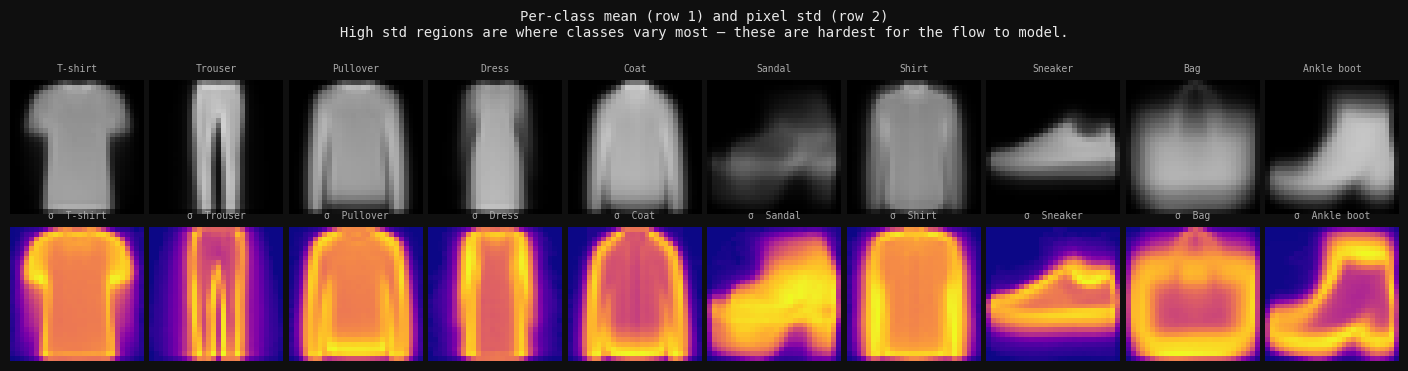

In [5]:
# Compute mean and std image per class
raw_data   = dataset.data.float() / 255.0
raw_labels = dataset.targets

class_means = []
class_stds  = []
for class_idx in range(10):
    mask = (raw_labels == class_idx)
    imgs = raw_data[mask]
    class_means.append(imgs.mean(0))
    class_stds.append(imgs.std(0))

class_means = torch.stack(class_means).unsqueeze(1)   # (10, 1, 28, 28)
class_stds  = torch.stack(class_stds).unsqueeze(1)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
fig.patch.set_facecolor('#0f0f0f')

for class_idx in range(10):
    # Mean
    ax = axes[0, class_idx]
    ax.imshow(class_means[class_idx, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
    ax.set_title(CLASS_NAMES[class_idx], color='#aaaaaa', fontsize=7)   # ← class name

    # Std
    ax = axes[1, class_idx]
    ax.imshow(class_stds[class_idx, 0].numpy(), cmap='plasma', vmin=0)
    ax.axis('off')
    ax.set_title(f'σ  {CLASS_NAMES[class_idx]}', color='#aaaaaa', fontsize=7)

plt.suptitle(
    'Per-class mean (row 1) and pixel std (row 2)\n'
    'High std regions are where classes vary most — these are hardest for the flow to model.',
    color='#e8e8e8', fontsize=10, y=1.05
)
plt.tight_layout(pad=0.4)
plt.show()

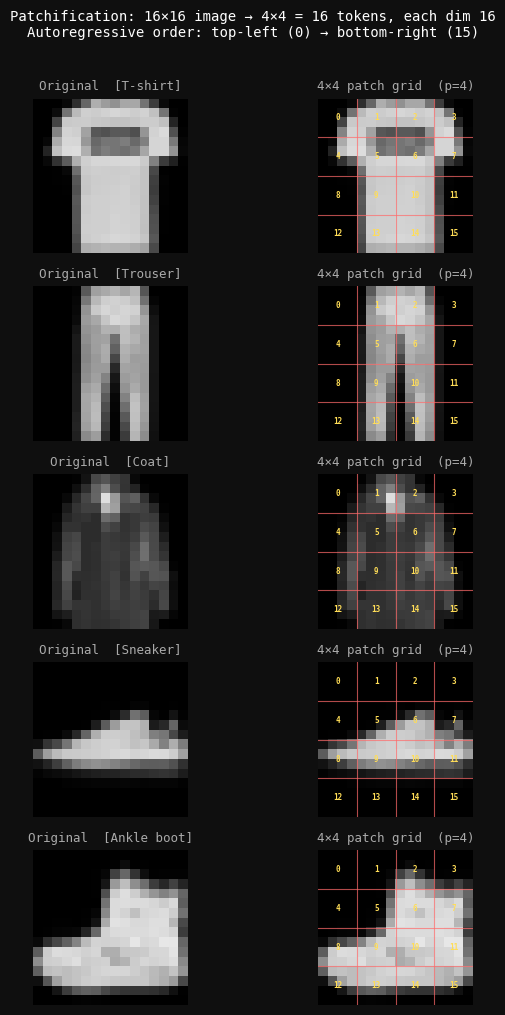

In [6]:
# Pick one image from each of five classes
demo_classes = [0, 1, 4, 7, 9]   # T-shirt, Trouser, Coat, Sneaker, Ankle boot
demo_imgs    = []
for d in demo_classes:
    idx = (dataset.targets == d).nonzero(as_tuple=True)[0][0].item()
    demo_imgs.append(dataset[idx][0])

fig, axes = plt.subplots(len(demo_classes), 2, figsize=(7, 10))
fig.patch.set_facecolor('#0f0f0f')

patch_size = cfg.patch_size
grid_n     = cfg.img_size // patch_size

for row, (class_idx, img) in enumerate(zip(demo_classes, demo_imgs)):
    # Original image
    ax = axes[row, 0]
    ax.imshow(((img[0] + 1) / 2).numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Original  [{CLASS_NAMES[class_idx]}]', color='#aaaaaa', fontsize=9)
    ax.axis('off')

    # Patch grid overlay
    ax2 = axes[row, 1]
    ax2.imshow(((img[0] + 1) / 2).numpy(), cmap='gray', vmin=0, vmax=1)
    for i in range(1, grid_n):
        ax2.axhline(i * patch_size - 0.5, color='#ff6b6b', linewidth=0.8, alpha=0.7)
        ax2.axvline(i * patch_size - 0.5, color='#ff6b6b', linewidth=0.8, alpha=0.7)
    for r in range(grid_n):
        for c in range(grid_n):
            patch_idx = r * grid_n + c
            ax2.text(
                c * patch_size + patch_size/2 - 0.5,
                r * patch_size + patch_size/2 - 0.5,
                str(patch_idx), ha='center', va='center',
                fontsize=5.5, color='#ffdd57', fontweight='bold'
            )
    ax2.set_title(f'{grid_n}×{grid_n} patch grid  (p={patch_size})', color='#aaaaaa', fontsize=9)
    ax2.axis('off')

plt.suptitle(
    f'Patchification: {cfg.img_size}×{cfg.img_size} image → '
    f'{grid_n}×{grid_n} = {cfg.num_patches} tokens, each dim {cfg.patch_dim}\n'
    f'Autoregressive order: top-left (0) → bottom-right ({cfg.num_patches-1})',
    color='#ffffff', fontsize=10, y=1.01
)
plt.tight_layout()
plt.show()

In [7]:
model = build_model(cfg, device=DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model architecture')
print(f'  Blocks           : {cfg.blocks}  (alternating identity / flip permutation)')
print(f'  Layers per block : {cfg.layers_per_block}')
print(f'  Transformer dim  : {cfg.channels}')
print(f'  NVP mode         : {cfg.nvp}')
print(f'  Num classes      : {cfg.num_classes}')
print()
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

Model architecture
  Blocks           : 4  (alternating identity / flip permutation)
  Layers per block : 4
  Transformer dim  : 128
  NVP mode         : True
  Num classes      : 10

Total parameters     : 3,210,880
Trainable parameters : 3,210,880


In [13]:
trainer = Trainer(model, train_loader, cfg, device=DEVICE)
history = trainer.train()

-------------------------- TARFlow Training --------------------------
  Device         : cpu
  Parameters     : 3,210,880
  Epochs         : 50
  Batch size     : 256
  Noise type     : gaussian  (σ=0.05)
  Label drop     : 0.1



c:\Users\sarpg\projects\master_thesis\STARFlow\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  Ep [  1/50] Step [ 200/234] loss=-0.2861  nll=0.4382  logdet=0.7243  lr=8.56e-05


c:\Users\sarpg\projects\master_thesis\Reimplementation\tarflow_train.py:280: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  m['block_norms'] = [float(z.pow(2).mean()) for z in outputs]



Epoch   1/50 | loss=-0.3834 | nll=0.4457 | logdet=0.8291 | block_norms=[0.8495 0.9826 0.7383 1.0151]

  Ep [  2/50] Step [ 200/234] loss=-1.2395  nll=0.4881  logdet=1.7276  lr=9.99e-05

Epoch   2/50 | loss=-1.2615 | nll=0.4884 | logdet=1.7499 | block_norms=[0.8171 0.6480 0.4962 0.9580]

  Ep [  3/50] Step [ 200/234] loss=-1.4681  nll=0.4893  logdet=1.9573  lr=9.97e-05

Epoch   3/50 | loss=-1.4763 | nll=0.4892 | logdet=1.9654 | block_norms=[0.7616 0.5815 0.4673 0.9690]

  Ep [  4/50] Step [ 200/234] loss=-1.5681  nll=0.4911  logdet=2.0591  lr=9.92e-05

Epoch   4/50 | loss=-1.5732 | nll=0.4912 | logdet=2.0644 | block_norms=[0.7057 0.5058 0.4480 0.9243]

  Ep [  5/50] Step [ 200/234] loss=-1.6302  nll=0.4944  logdet=2.1246  lr=9.85e-05

Epoch   5/50 | loss=-1.6341 | nll=0.4946 | logdet=2.1287 | block_norms=[0.6764 0.4869 0.4483 1.0413]

  Ep [  6/50] Step [ 200/234] loss=-1.6725  nll=0.4964  logdet=2.1688  lr=9.76e-05

Epoch   6/50 | loss=-1.6748 | nll=0.4964 | logdet=2.1712 | block_norm

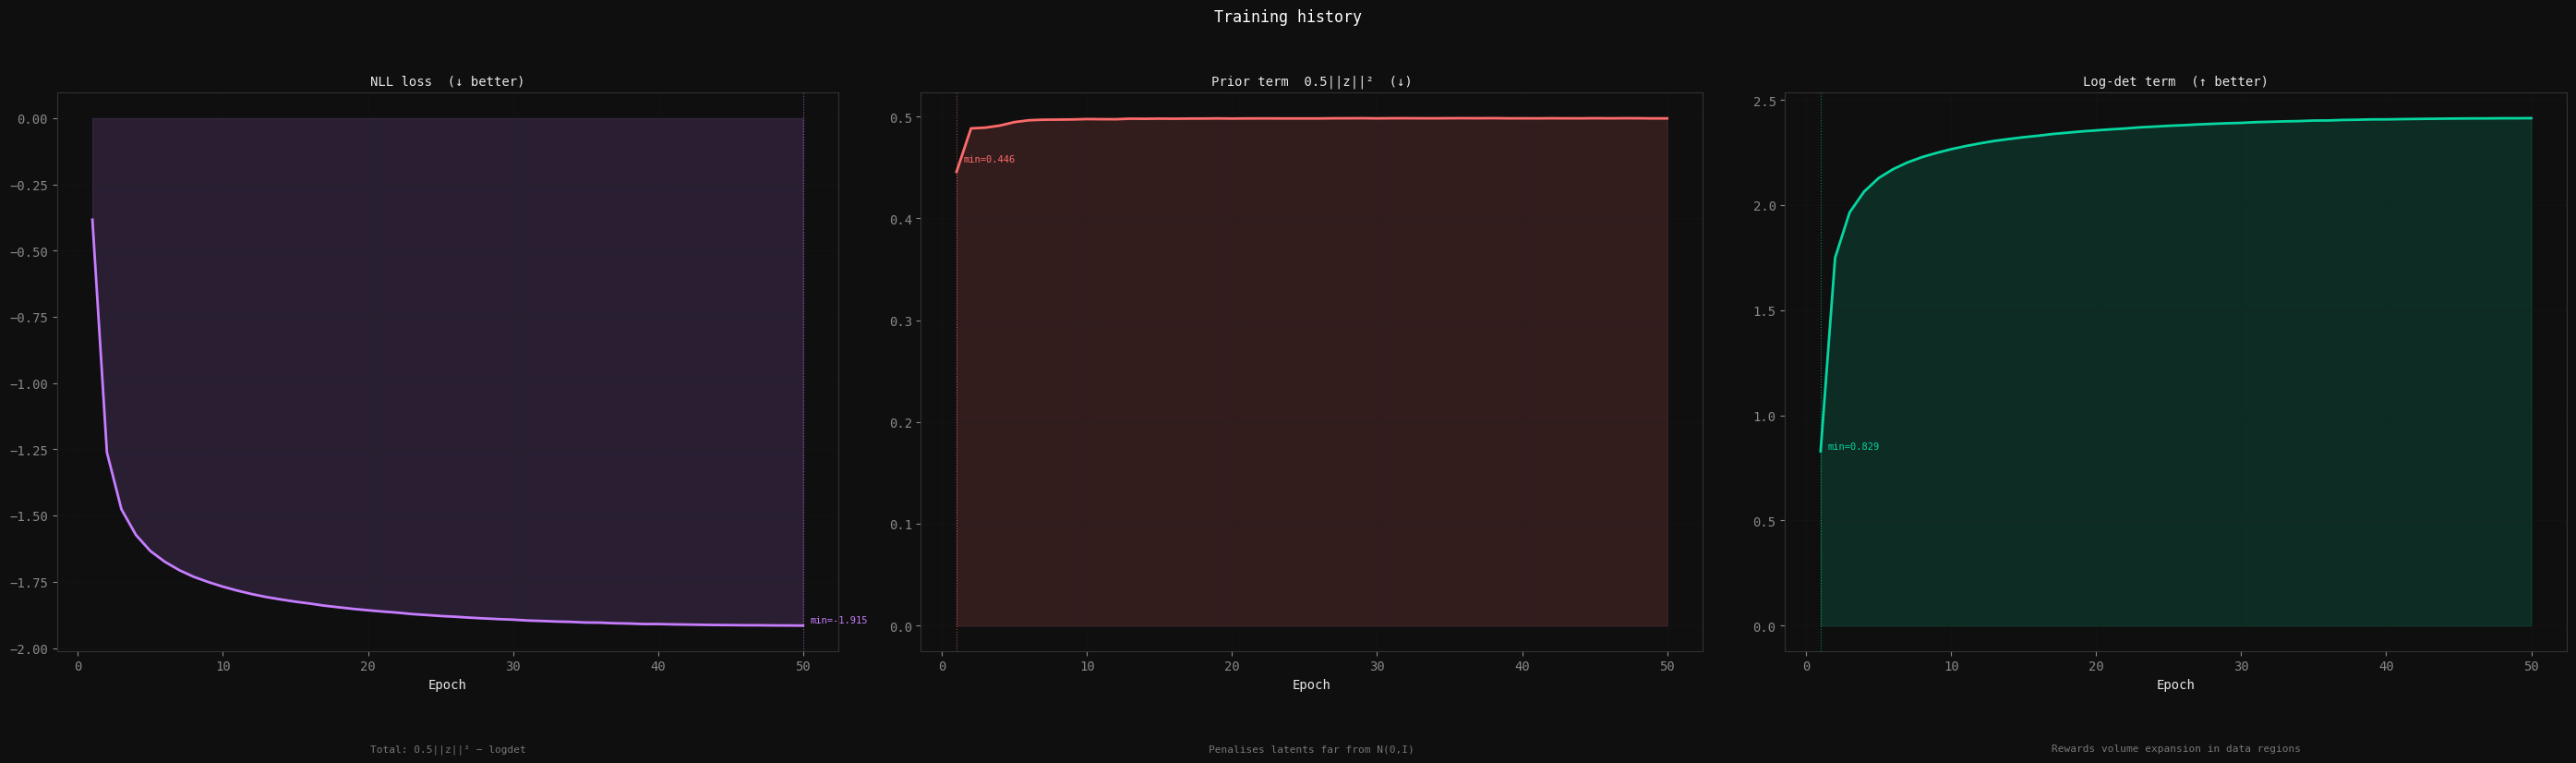

Final loss   : -1.9155
Final nll    : 0.4983
Final logdet : 2.4137


In [16]:
epochs_axis = list(range(1, len(history['loss']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(28, 8))
fig.patch.set_facecolor('#0f0f0f')

plot_specs = [
    ('loss',    '#c77dff', 'NLL loss  (↓ better)',            'Total: 0.5||z||² − logdet'),
    ('nll',     '#ff6b6b', 'Prior term  0.5||z||²  (↓)',      'Penalises latents far from N(0,I)'),
    ('logdet',  '#06d6a0', 'Log-det term  (↑ better)',        'Rewards volume expansion in data regions'),
]

for ax, (key, color, title, subtitle) in zip(axes, plot_specs):
    ax.plot(epochs_axis, history[key], color=color, linewidth=2)
    ax.fill_between(epochs_axis, history[key], alpha=0.15, color=color)
    ax.set_title(title, color='#e8e8e8', fontsize=10, pad=6)
    ax.set_xlabel('Epoch')
    ax.text(0.5, -0.18, subtitle, transform=ax.transAxes,
            ha='center', color='#777777', fontsize=8)
    ax.grid(alpha=0.2)
    min_val = min(history[key])
    min_ep  = history[key].index(min_val) + 1
    ax.axvline(min_ep, color=color, linewidth=0.8, linestyle=':', alpha=0.6)
    ax.annotate(f'min={min_val:.3f}', xy=(min_ep, min_val),
                xytext=(min_ep + 0.5, min_val + 0.01),
                color=color, fontsize=7.5)

plt.suptitle('Training history', color='#ffffff', fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

print(f'Final loss   : {history["loss"][-1]:.4f}')
print(f'Final nll    : {history["nll"][-1]:.4f}')
print(f'Final logdet : {history["logdet"][-1]:.4f}')

In [8]:
model.load_state_dict(torch.load('runs_fmnist/model.pth', map_location=DEVICE))
model.eval()

print(f'Model loaded  — {sum(p.numel() for p in model.parameters()):,} parameters')
print(f'Device        — {DEVICE}')

Model loaded  — 3,210,880 parameters
Device        — cpu


In [9]:
model.eval()

# Default SampleConfig
base_cfg = SampleConfig(
    guidance          = 2.0,
    guide_what        = 'ab',
    annealed_guidance = False,
    attn_temp         = 1.0,
    denoise           = False,
    noise_std         = cfg.noise_std,   
    denoise_steps     = 1,
    clip_output       = True,
)

sampler = Sampler(model, base_cfg)

# Labels: one of each digit, repeated — 40 samples, 4 per class
LABELS_40  = list(range(10)) * 4
LABELS_10  = list(range(10))
N_PLAIN    = 40
GUIDANCE_W = 2.0

print('Sampler ready.')
print(f'Device         : {sampler.device}')
print(f'Num patches    : {sampler._num_patches}')
print(f'Patch dim      : {sampler._patch_dim}')

Sampler ready.
Device         : cpu
Num patches    : 16
Patch dim      : 16


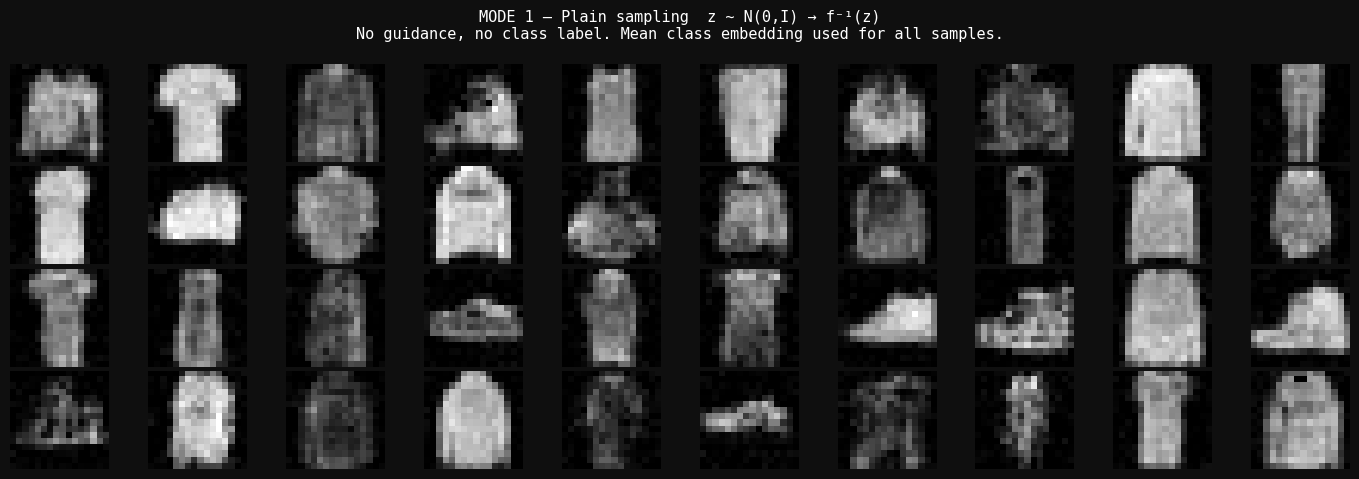

In [10]:
plain_samples = sampler.sample_plain(n=N_PLAIN)

show_grid(
    plain_samples,
    nrow=10,
    figsize=(14, 4.5),
    suptitle='MODE 1 — Plain sampling  z ~ N(0,I) → f⁻¹(z)\n'
             'No guidance, no class label. Mean class embedding used for all samples.',
)

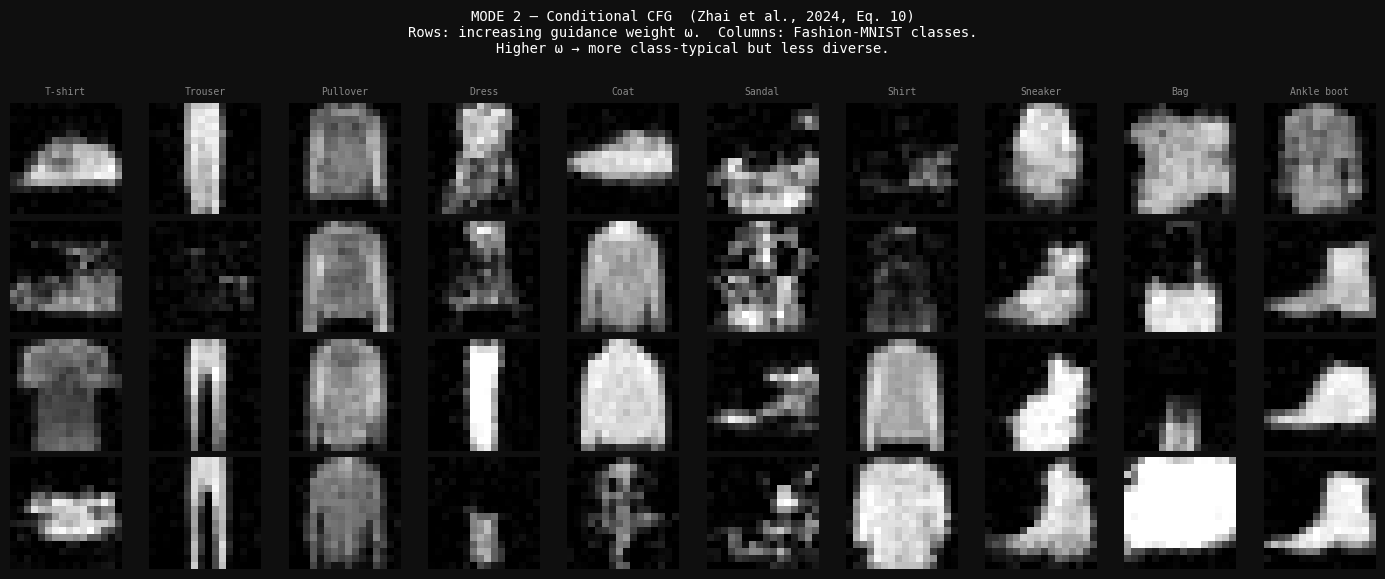

In [11]:
guidance_weights = [0.0, 1.0, 2.0, 3.0]
labels_10        = list(range(10))

fig, axes = plt.subplots(
    len(guidance_weights), 10,
    figsize=(14, 5.5)
)
fig.patch.set_facecolor('#0f0f0f')

for row, w in enumerate(guidance_weights):
    samples = sampler.sample_conditional(labels=labels_10, guidance=w)
    imgs    = ((samples.cpu() + 1) / 2).clamp(0, 1)

    for col in range(10):
        ax = axes[row, col]
        ax.imshow(imgs[col, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if row == 0:
            ax.set_title(CLASS_NAMES[col], color='#888888', fontsize=7)   # ← class name

    axes[row, 0].set_ylabel(f'ω = {w}', color='#c77dff', fontsize=9, rotation=0,
                             labelpad=38, va='center')

plt.suptitle(
    'MODE 2 — Conditional CFG  (Zhai et al., 2024, Eq. 10)\n'
    'Rows: increasing guidance weight ω.  Columns: Fashion-MNIST classes.\n'
    'Higher ω → more class-typical but less diverse.',
    color='#ffffff', fontsize=10, y=1.03
)
plt.tight_layout(pad=0.5)
plt.show()

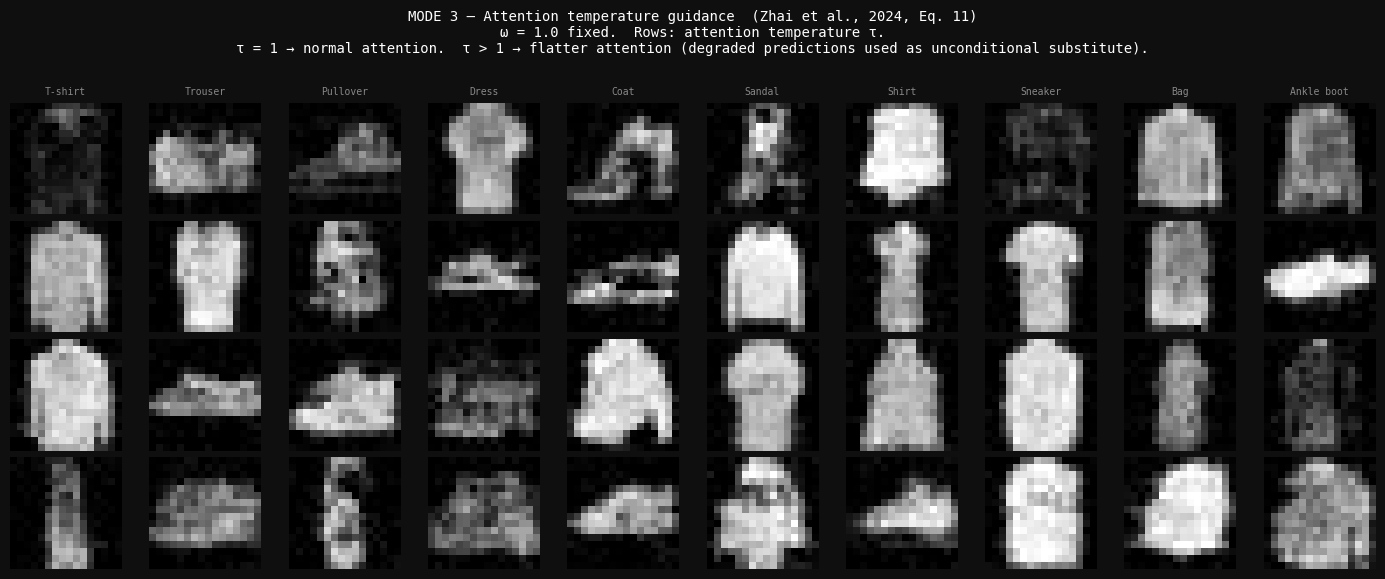

In [12]:
temps    = [1.0, 1.2, 1.5, 2.0]
guidance = 1.0

fig, axes = plt.subplots(len(temps), 10, figsize=(14, 5.5))
fig.patch.set_facecolor('#0f0f0f')

for row, tau in enumerate(temps):
    samples = sampler.sample_temperature_guided(n=10, guidance=guidance, attn_temp=tau)
    imgs    = ((samples.cpu() + 1) / 2).clamp(0, 1)

    for col in range(10):
        ax = axes[row, col]
        ax.imshow(imgs[col, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if row == 0:
            ax.set_title(CLASS_NAMES[col], color='#888888', fontsize=7)   # ← class name

    axes[row, 0].set_ylabel(f'τ = {tau}', color='#06d6a0', fontsize=9,
                             rotation=0, labelpad=38, va='center')

plt.suptitle(
    'MODE 3 — Attention temperature guidance  (Zhai et al., 2024, Eq. 11)\n'
    f'ω = {guidance} fixed.  Rows: attention temperature τ.\n'
    'τ = 1 → normal attention.  τ > 1 → flatter attention (degraded predictions used as unconditional substitute).',
    color='#ffffff', fontsize=10, y=1.03
)
plt.tight_layout(pad=0.5)
plt.show()

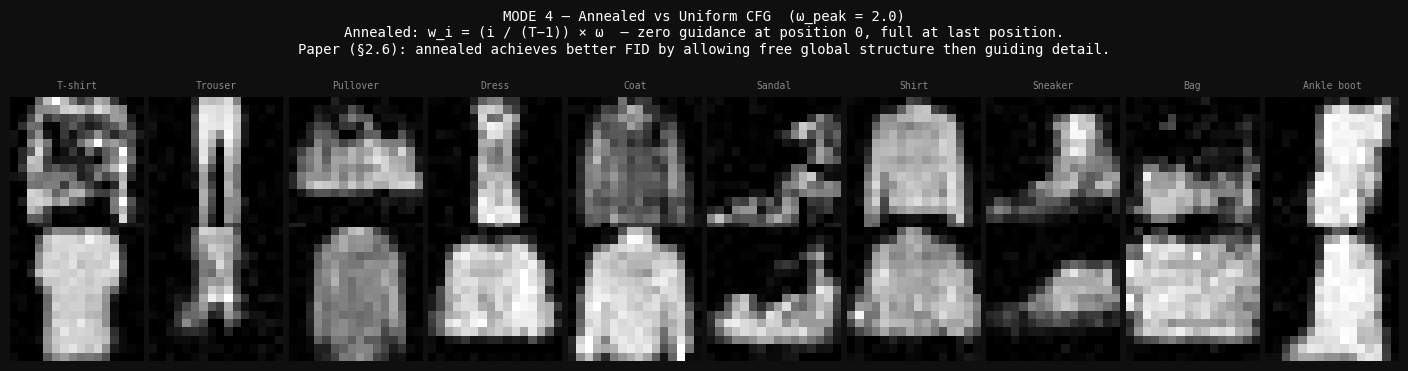

In [13]:
labels_row = list(range(10))

uniform_samples  = sampler.sample_conditional(labels=labels_row, guidance=GUIDANCE_W)
annealed_samples = sampler.sample_annealed(labels=labels_row,    guidance=GUIDANCE_W)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
fig.patch.set_facecolor('#0f0f0f')

for col in range(10):
    for row, (samples, label) in enumerate([
        (uniform_samples,  'Uniform guidance'),
        (annealed_samples, 'Annealed guidance'),
    ]):
        img = ((samples[col].cpu() + 1) / 2).clamp(0, 1)
        axes[row, col].imshow(img[0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(CLASS_NAMES[col], color='#888888', fontsize=7)  # ← class name

axes[0, 0].set_ylabel('Uniform\nω = const', color='#ff9f1c', fontsize=8,
                       rotation=0, labelpad=50, va='center')
axes[1, 0].set_ylabel('Annealed\nω grows', color='#ff9f1c', fontsize=8,
                       rotation=0, labelpad=50, va='center')

plt.suptitle(
    f'MODE 4 — Annealed vs Uniform CFG  (ω_peak = {GUIDANCE_W})\n'
    'Annealed: w_i = (i / (T−1)) × ω  — zero guidance at position 0, full at last position.\n'
    'Paper (§2.6): annealed achieves better FID by allowing free global structure then guiding detail.',
    color='#ffffff', fontsize=10, y=1.05
)
plt.tight_layout(pad=0.4)
plt.show()

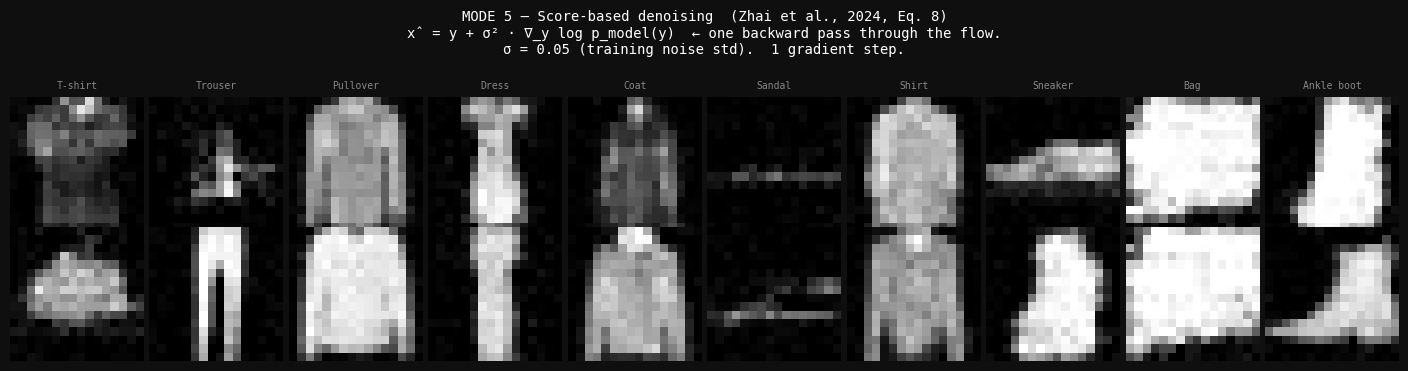

Mean absolute denoising correction : 0.3909
Max  absolute denoising correction : 2.0000


In [14]:
labels_row  = list(range(10))

raw_samples      = sampler.sample_conditional(labels=labels_row, guidance=GUIDANCE_W)
denoised_samples = sampler.sample_denoised(n=10, labels=labels_row,
                                           guidance=GUIDANCE_W,
                                           noise_std=cfg.noise_std)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
fig.patch.set_facecolor('#0f0f0f')

for col in range(10):
    for row, (samples, label) in enumerate([
        (raw_samples,      'Raw'),
        (denoised_samples, 'Denoised'),
    ]):
        img = ((samples[col].cpu() + 1) / 2).clamp(0, 1)
        axes[row, col].imshow(img[0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(CLASS_NAMES[col], color='#888888', fontsize=7)  # ← class name

axes[0, 0].set_ylabel('Raw\nf⁻¹(z)', color='#ff6b6b', fontsize=8,
                       rotation=0, labelpad=38, va='center')
axes[1, 0].set_ylabel('Denoised\nTweedie', color='#06d6a0', fontsize=8,
                       rotation=0, labelpad=38, va='center')

plt.suptitle(
    'MODE 5 — Score-based denoising  (Zhai et al., 2024, Eq. 8)\n'
    'x̂ = y + σ² · ∇_y log p_model(y)  ← one backward pass through the flow.\n'
    f'σ = {cfg.noise_std} (training noise std).  1 gradient step.',
    color='#ffffff', fontsize=10, y=1.05
)
plt.tight_layout(pad=0.4)
plt.show()

diff = (denoised_samples - raw_samples).abs().cpu()
print(f'Mean absolute denoising correction : {diff.mean():.4f}')
print(f'Max  absolute denoising correction : {diff.max():.4f}')

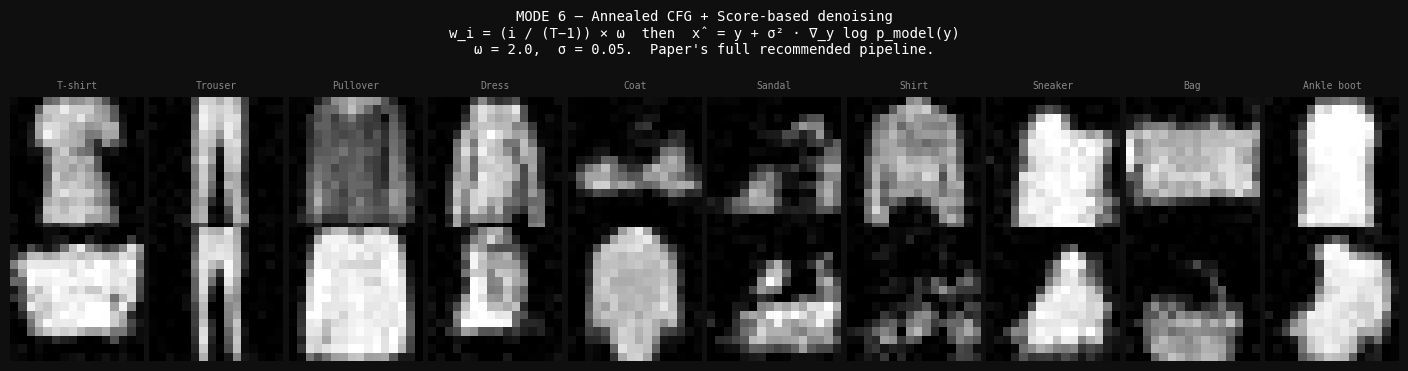

Mean absolute denoising correction : 0.5202
Max  absolute denoising correction : 2.0000


In [15]:
labels_row       = list(range(10))

annealed_raw     = sampler.sample_annealed(labels=labels_row, guidance=GUIDANCE_W)
annealed_denoised = sampler.sample_denoised(n=10, labels=labels_row,
                                            guidance=GUIDANCE_W,
                                            noise_std=cfg.noise_std,
                                            annealed=True)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
fig.patch.set_facecolor('#0f0f0f')

for col in range(10):
    for row, (samples, label) in enumerate([
        (annealed_raw,      'Annealed raw'),
        (annealed_denoised, 'Annealed denoised'),
    ]):
        img = ((samples[col].cpu() + 1) / 2).clamp(0, 1)
        axes[row, col].imshow(img[0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(CLASS_NAMES[col], color='#888888', fontsize=7)

axes[0, 0].set_ylabel('Annealed\nRaw', color='#ff9f1c', fontsize=8,
                       rotation=0, labelpad=38, va='center')
axes[1, 0].set_ylabel('Annealed\nDenoised', color='#06d6a0', fontsize=8,
                       rotation=0, labelpad=38, va='center')

plt.suptitle(
    'MODE 6 — Annealed CFG + Score-based denoising\n'
    'w_i = (i / (T−1)) × ω  then  x̂ = y + σ² · ∇_y log p_model(y)\n'
    f'ω = {GUIDANCE_W},  σ = {cfg.noise_std}.  Paper\'s full recommended pipeline.',
    color='#ffffff', fontsize=10, y=1.05
)
plt.tight_layout(pad=0.4)
plt.show()

diff = (annealed_denoised - annealed_raw).abs().cpu()
print(f'Mean absolute denoising correction : {diff.mean():.4f}')
print(f'Max  absolute denoising correction : {diff.max():.4f}')

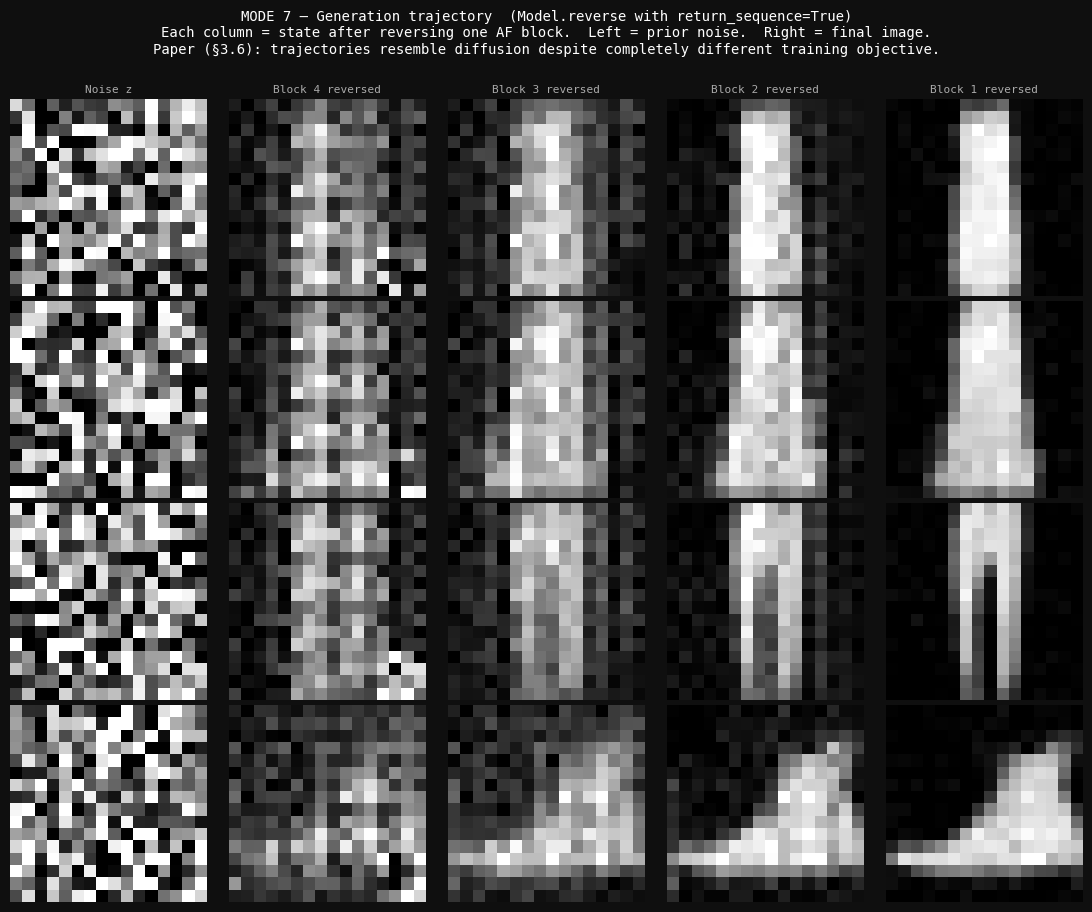

Number of trajectory frames : 5  (1 noise + 4 blocks)


In [16]:
n_traj   = 4
traj_labels = [3, 7, 1, 9]

frames = sampler.sample_trajectory(n=n_traj, labels=traj_labels, guidance=GUIDANCE_W)
# frames is a list of length (num_blocks + 1), each tensor (n_traj, 1, 28, 28)

n_steps = len(frames)
step_labels = ['Noise z'] + [f'Block {cfg.blocks - i} reversed' for i in range(cfg.blocks)]

fig, axes = plt.subplots(n_traj, n_steps, figsize=(n_steps * 2.2, n_traj * 2.2))
fig.patch.set_facecolor('#0f0f0f')

for row in range(n_traj):
    for col, frame in enumerate(frames):
        ax  = axes[row, col]
        img = ((frame[row].cpu() + 1) / 2).clamp(0, 1)
        ax.imshow(img[0].numpy(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if row == 0:
            ax.set_title(step_labels[col], color='#aaaaaa', fontsize=8, pad=4)
    axes[row, 0].set_ylabel(f'digit {traj_labels[row]}', color='#c77dff',
                             fontsize=8, rotation=0, labelpad=40, va='center')

# Draw arrows between columns
plt.suptitle(
    'MODE 7 — Generation trajectory  (Model.reverse with return_sequence=True)\n'
    'Each column = state after reversing one AF block.  Left = prior noise.  Right = final image.\n'
    'Paper (§3.6): trajectories resemble diffusion despite completely different training objective.',
    color='#ffffff', fontsize=10, y=1.02
)
plt.tight_layout(pad=0.4)
plt.show()

print(f'Number of trajectory frames : {len(frames)}  (1 noise + {cfg.blocks} blocks)')

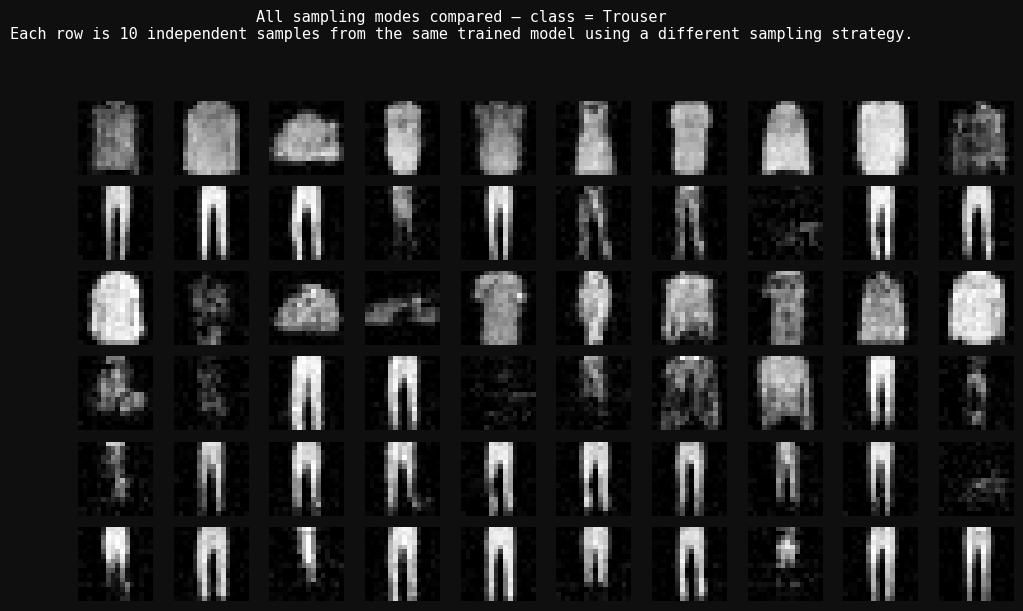

In [19]:
TARGET_CLASS = 1   # Sandal — visually distinctive, good for comparison
N_COMPARE    = 10
labels_same  = [TARGET_CLASS] * N_COMPARE

modes = [
    ('Mode 1 — Plain',                    sampler.sample_plain(n=N_COMPARE)),
    ('Mode 2 — Conditional CFG (ω=2)',    sampler.sample_conditional(labels_same, guidance=2.0)),
    ('Mode 3 — Temp-guided (τ=1.5,ω=1)', sampler.sample_temperature_guided(N_COMPARE, guidance=1.0, attn_temp=1.5)),
    ('Mode 4 — Annealed CFG (ω=2)',       sampler.sample_annealed(labels_same, guidance=2.0)),
    ('Mode 5 — Conditional CFG + Denoised (ω=2, σ=0.05)',  sampler.sample_denoised(N_COMPARE, labels_same, guidance=2.0)),
    ('Mode 6 — Annealed + Denoised',       sampler.sample_denoised(N_COMPARE, labels_same, guidance=2.0, annealed=True)),
]

mode_colors = ['#888888', '#c77dff', '#06d6a0', '#ff9f1c', '#ff6b6b', '#00b4d8']
#                                                                        
fig, axes = plt.subplots(len(modes), N_COMPARE, figsize=(14, 6.5))
fig.patch.set_facecolor('#0f0f0f')

for row, ((mode_name, samples), color) in enumerate(zip(modes, mode_colors)):
    imgs = ((samples.cpu() + 1) / 2).clamp(0, 1)
    for col in range(N_COMPARE):
        ax = axes[row, col]
        ax.imshow(imgs[col, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_visible(False)
    axes[row, 0].set_ylabel(mode_name, color=color, fontsize=8,
                             rotation=0, labelpad=160, va='center')

plt.suptitle(
    f'All sampling modes compared — class = {CLASS_NAMES[TARGET_CLASS]}\n'
    'Each row is 10 independent samples from the same trained model using a different sampling strategy.',
    color='#ffffff', fontsize=11, y=1.02
)
plt.subplots_adjust(left=0.22, wspace=0.05, hspace=0.15)
plt.show()

c:\Users\sarpg\projects\master_thesis\STARFlow\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


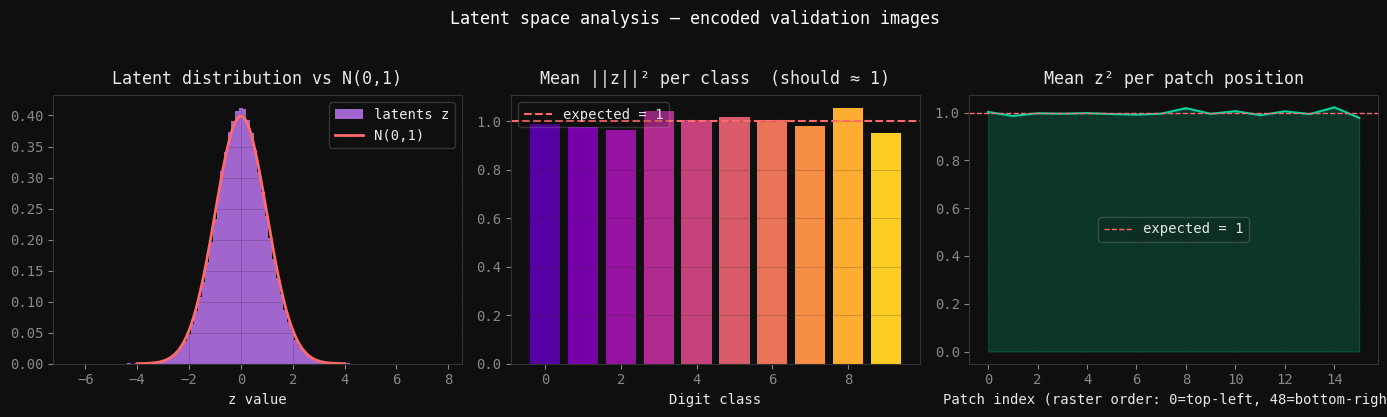

Latent mean  : 0.0003  (should be ≈ 0)
Latent std   : 0.9992   (should be ≈ 1)
Latent shape : torch.Size([2560, 16, 16])


In [20]:
model.eval()
all_z, all_labels_list = [], []

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(val_loader):
        if batch_idx >= 10:   # 10 batches × 128 = ~1280 images
            break
        x = x.to(DEVICE)
        # Add the same noise as training so the encoding is in-distribution
        x_noisy = x + cfg.noise_std * torch.randn_like(x)
        z, _, _ = model(x_noisy)
        all_z.append(z.cpu())
        all_labels_list.append(y)

all_z      = torch.cat(all_z,           dim=0)   # (N, 49, 16)
all_labels_t = torch.cat(all_labels_list, dim=0)

# Flatten to (N, 49*16) for statistics
z_flat = all_z.reshape(all_z.shape[0], -1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor('#0f0f0f')

# --- Histogram of all latent values vs N(0,1) ---
ax = axes[0]
z_vals = z_flat.numpy().flatten()
ax.hist(z_vals, bins=100, density=True, color='#c77dff', alpha=0.8, label='latents z')
xs = np.linspace(-4, 4, 300)
ax.plot(xs, np.exp(-0.5 * xs**2) / np.sqrt(2 * np.pi),
        color='#ff6b6b', linewidth=2, label='N(0,1)')
ax.set_title('Latent distribution vs N(0,1)', color='#e8e8e8', pad=8)
ax.set_xlabel('z value')
ax.legend(framealpha=0.2)
ax.grid(alpha=0.2)

# --- Per-class mean latent norm ---
ax = axes[1]
class_norms = []
for digit in range(10):
    mask = (all_labels_t == digit)
    class_norms.append(z_flat[mask].pow(2).mean().item())
bar_colors = plt.cm.plasma(np.linspace(0.15, 0.9, 10))
ax.bar(range(10), class_norms, color=bar_colors)
ax.axhline(1.0, color='#ff6b6b', linewidth=1.5, linestyle='--', label='expected = 1')
ax.set_title('Mean ||z||² per class  (should ≈ 1)', color='#e8e8e8', pad=8)
ax.set_xlabel('Digit class')
ax.legend(framealpha=0.2)
ax.grid(axis='y', alpha=0.2)

# --- Latent variance across patch positions ---
ax = axes[2]
patch_var = all_z.pow(2).mean(dim=[0, 2]).numpy()   # (49,) mean over batch and channel
ax.plot(range(len(patch_var)), patch_var, color='#06d6a0', linewidth=1.5)
ax.fill_between(range(len(patch_var)), patch_var, alpha=0.2, color='#06d6a0')
ax.axhline(1.0, color='#ff6b6b', linewidth=1, linestyle='--', label='expected = 1')
ax.set_title('Mean z² per patch position', color='#e8e8e8', pad=8)
ax.set_xlabel('Patch index (raster order: 0=top-left, 48=bottom-right)')
ax.legend(framealpha=0.2)
ax.grid(alpha=0.2)

plt.suptitle('Latent space analysis — encoded validation images', color='#ffffff', fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

print(f'Latent mean  : {z_flat.mean():.4f}  (should be ≈ 0)')
print(f'Latent std   : {z_flat.std():.4f}   (should be ≈ 1)')
print(f'Latent shape : {all_z.shape}')

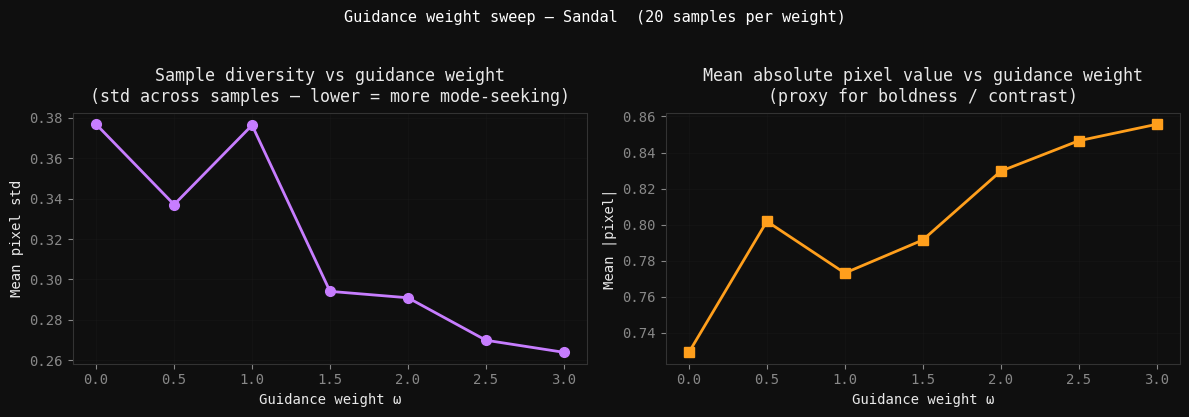

In [21]:
guidance_sweep = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
n_per_w        = 20
TARGET_CLASS   = 5                          # Sandal — matches the comparison cell
labels_w       = [TARGET_CLASS] * n_per_w

mean_stds   = []
mean_norms  = []

for w in guidance_sweep:
    samples = sampler.sample_conditional(labels=labels_w, guidance=w)
    mean_stds.append(samples.std(dim=0).mean().item())
    mean_norms.append(samples.abs().mean().item())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0f0f0f')

ax = axes[0]
ax.plot(guidance_sweep, mean_stds, 'o-', color='#c77dff', linewidth=2, markersize=7)
ax.set_title('Sample diversity vs guidance weight\n(std across samples — lower = more mode-seeking)',
             color='#e8e8e8', pad=8)
ax.set_xlabel('Guidance weight ω')
ax.set_ylabel('Mean pixel std')
ax.grid(alpha=0.25)

ax = axes[1]
ax.plot(guidance_sweep, mean_norms, 's-', color='#ff9f1c', linewidth=2, markersize=7)
ax.set_title('Mean absolute pixel value vs guidance weight\n(proxy for boldness / contrast)',
             color='#e8e8e8', pad=8)
ax.set_xlabel('Guidance weight ω')
ax.set_ylabel('Mean |pixel|')
ax.grid(alpha=0.25)

plt.suptitle(
    f'Guidance weight sweep — {CLASS_NAMES[TARGET_CLASS]}  ({n_per_w} samples per weight)',
    color='#ffffff', fontsize=11, y=1.03
)
plt.tight_layout()
plt.show()

Training classifier...
  Epoch  1/20  train_acc=0.835  lr=9.94e-04
  Epoch  2/20  train_acc=0.891  lr=9.76e-04
  Epoch  3/20  train_acc=0.905  lr=9.46e-04
  Epoch  4/20  train_acc=0.915  lr=9.05e-04
  Epoch  5/20  train_acc=0.922  lr=8.54e-04
  Epoch  6/20  train_acc=0.928  lr=7.94e-04
  Epoch  7/20  train_acc=0.934  lr=7.27e-04
  Epoch  8/20  train_acc=0.943  lr=6.55e-04
  Epoch  9/20  train_acc=0.950  lr=5.78e-04
  Epoch 10/20  train_acc=0.955  lr=5.00e-04
  Epoch 11/20  train_acc=0.962  lr=4.22e-04
  Epoch 12/20  train_acc=0.969  lr=3.45e-04
  Epoch 13/20  train_acc=0.975  lr=2.73e-04
  Epoch 14/20  train_acc=0.981  lr=2.06e-04
  Epoch 15/20  train_acc=0.986  lr=1.46e-04
  Epoch 16/20  train_acc=0.990  lr=9.55e-05
  Epoch 17/20  train_acc=0.993  lr=5.45e-05
  Epoch 18/20  train_acc=0.995  lr=2.45e-05
  Epoch 19/20  train_acc=0.996  lr=6.16e-06
  Epoch 20/20  train_acc=0.997  lr=0.00e+00

Mode                        Accuracy  Diversity  Sharpness   L2-dist   Mini-FD
-----------------

C:\Users\sarpg\AppData\Local\Temp\ipykernel_5072\1587523559.py:152: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = linalg.sqrtm(cov_g @ cov_r)


Mode 3 — Temp-guided           0.175     0.4470     0.2244   10.6968      3.94
Mode 4 — Annealed CFG          0.800     0.3748     0.2196    9.2908     16.55
Mode 5 — CFG + Denoised        0.825     0.3557     0.2386    9.0088     22.87
Mode 6 — Annealed + Denoised     0.900     0.3388     0.2246    8.7572     24.40


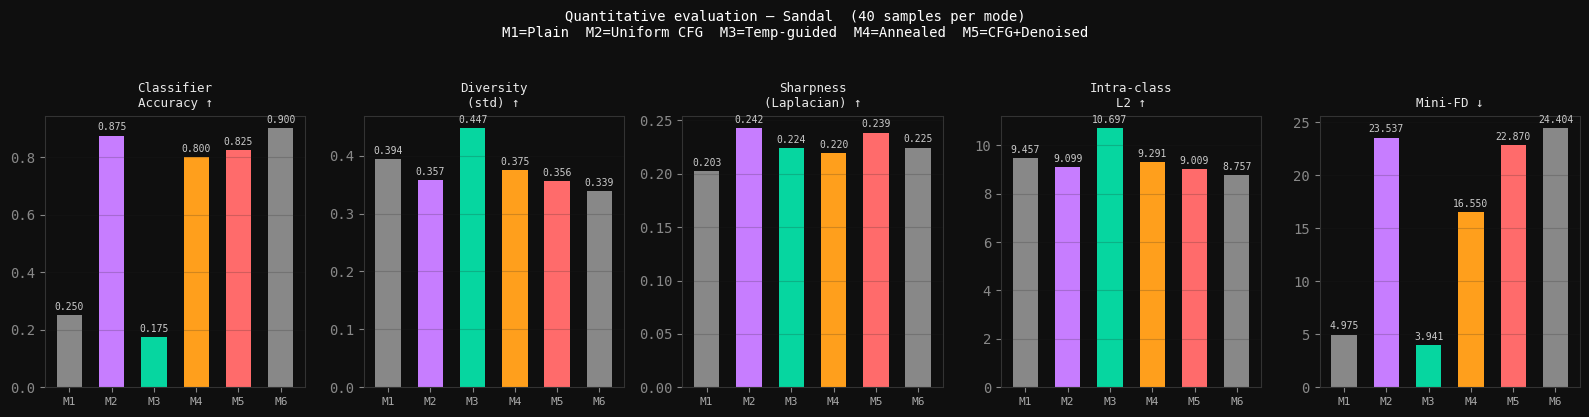

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy import linalg

# =============================================================================
# STEP 1 — Train a tiny classifier (run once, takes ~2 minutes on CPU)
# =============================================================================

class TinyClassifier(nn.Module):
    def __init__(self, img_size=16, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * (img_size//4) * (img_size//4), 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def train_classifier(train_loader, img_size, device, epochs=10):
    clf = TinyClassifier(img_size=img_size).to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    for epoch in range(epochs):
        clf.train()
        correct, total = 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            # Normalise [-1,1] → [0,1] — must match evaluation
            x_in = ((x + 1) / 2).clamp(0, 1)
            logits = clf(x_in)
            loss   = F.cross_entropy(logits, y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            correct += (logits.argmax(1) == y).sum().item()
            total   += y.size(0)
        sched.step()
        print(f'  Epoch {epoch+1:2d}/{epochs}  '
              f'train_acc={correct/total:.3f}  '
              f'lr={sched.get_last_lr()[0]:.2e}')

    clf.eval()
    return clf

print('Training classifier...')
classifier = train_classifier(train_loader, cfg.img_size, DEVICE, epochs=20)

# =============================================================================
# STEP 2 — Collect real reference samples for mini-FD
# =============================================================================

def get_real_samples(val_loader, n=200, device='cpu'):
    """Collect n real images from the validation set."""
    imgs = []
    for x, _ in val_loader:
        imgs.append(x)
        if sum(i.shape[0] for i in imgs) >= n:
            break
    return torch.cat(imgs)[:n].to(device)

real_samples = get_real_samples(val_loader, n=200, device=DEVICE)


# =============================================================================
# STEP 3 — Metric functions
# =============================================================================

def compute_classifier_accuracy(samples, labels, classifier, device):
    """
    Fraction of generated samples correctly classified as their intended class.
    A well-trained conditional model should score above 0.7 at moderate guidance.
    """
    classifier.eval()
    samples_01 = ((samples.to(device) + 1) / 2).clamp(0, 1)
    labels_t   = torch.tensor(labels, device=device)
    with torch.no_grad():
        preds = classifier(samples_01).argmax(dim=1)
    return (preds == labels_t).float().mean().item()


def compute_diversity(samples):
    """
    Mean pixel std across samples — measures spread within the generated set.
    Higher = more diverse. Lower = more mode-collapsed.
    """
    return samples.std(dim=0).mean().item()


def compute_sharpness(samples):
    """
    Mean Laplacian response — measures image sharpness.
    Laplacian kernel detects edges; blurry images have low response.
    Higher = sharper.
    """
    laplacian_kernel = torch.tensor(
        [[0, 1, 0],
         [1,-4, 1],
         [0, 1, 0]], dtype=torch.float32
    ).view(1, 1, 3, 3)

    imgs = ((samples + 1) / 2).clamp(0, 1)
    lap  = F.conv2d(imgs, laplacian_kernel, padding=1)
    return lap.abs().mean().item()


def compute_intraclass_l2(samples):
    """
    Mean pairwise L2 distance between samples (flattened).
    Proxy for perceptual diversity within the generated batch.
    Higher = more varied samples.
    """
    flat = samples.view(samples.shape[0], -1).float()
    # Compute pairwise distances efficiently
    dists = torch.cdist(flat, flat, p=2)
    # Upper triangle only (avoid diagonal and double-counting)
    n = flat.shape[0]
    mask = torch.triu(torch.ones(n, n), diagonal=1).bool()
    return dists[mask].mean().item()


def compute_mini_fd(generated, real):
    """
    Fréchet Distance between pixel-space Gaussian statistics of
    generated and real images. Cheaper than full FID — no Inception network.
    Lower = closer to real distribution.
    """
    def get_stats(imgs):
        flat = ((imgs + 1) / 2).clamp(0, 1)
        flat = flat.view(flat.shape[0], -1).float().cpu().numpy()
        mu   = flat.mean(axis=0)
        cov  = np.cov(flat, rowvar=False)
        return mu, cov

    mu_g, cov_g = get_stats(generated)
    mu_r, cov_r = get_stats(real)

    diff    = mu_g - mu_r
    covmean = linalg.sqrtm(cov_g @ cov_r)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fd = diff @ diff + np.trace(cov_g + cov_r - 2 * covmean)
    return float(fd)


# =============================================================================
# STEP 4 — Evaluate all modes
# =============================================================================

TARGET_CLASS = 5
N_EVAL       = 40          # samples per mode — keep small for speed
labels_eval  = [TARGET_CLASS] * N_EVAL

modes_eval = [
    ('Mode 1 — Plain',            sampler.sample_plain(n=N_EVAL)),
    ('Mode 2 — Uniform CFG',      sampler.sample_conditional(labels_eval, guidance=2.0)),
    ('Mode 3 — Temp-guided',      sampler.sample_temperature_guided(N_EVAL, guidance=1.0, attn_temp=1.5)),
    ('Mode 4 — Annealed CFG',     sampler.sample_annealed(labels_eval, guidance=2.0)),
    ('Mode 5 — CFG + Denoised',   sampler.sample_denoised(N_EVAL, labels_eval, guidance=2.0)),
    ('Mode 6 — Annealed + Denoised', sampler.sample_denoised(N_EVAL, labels_eval, guidance=2.0, annealed=True)),
]

print(f'\n{"Mode":<26} {"Accuracy":>9} {"Diversity":>10} {"Sharpness":>10} {"L2-dist":>9} {"Mini-FD":>9}')
print('-' * 78)

results = {}
for mode_name, samples in modes_eval:
    acc  = compute_classifier_accuracy(samples, labels_eval, classifier, DEVICE)
    div  = compute_diversity(samples)
    shrp = compute_sharpness(samples)
    l2   = compute_intraclass_l2(samples)
    fd   = compute_mini_fd(samples, real_samples)

    results[mode_name] = {
        'accuracy':  acc,
        'diversity': div,
        'sharpness': shrp,
        'l2_dist':   l2,
        'mini_fd':   fd,
    }
    print(f'{mode_name:<26} {acc:>9.3f} {div:>10.4f} {shrp:>10.4f} {l2:>9.4f} {fd:>9.2f}')


# =============================================================================
# STEP 5 — Plot results
# =============================================================================

import matplotlib.pyplot as plt

metric_keys   = ['accuracy', 'diversity', 'sharpness', 'l2_dist', 'mini_fd']
metric_labels = ['Classifier\nAccuracy ↑', 'Diversity\n(std) ↑',
                 'Sharpness\n(Laplacian) ↑', 'Intra-class\nL2 ↑', 'Mini-FD ↓']
mode_names    = [m for m, _ in modes_eval]
colors        = ['#888888', '#c77dff', '#06d6a0', '#ff9f1c', '#ff6b6b']

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.patch.set_facecolor('#0f0f0f')

for ax, key, label in zip(axes, metric_keys, metric_labels):
    vals = [results[m][key] for m in mode_names]
    bars = ax.bar(range(len(mode_names)), vals, color=colors, width=0.6)
    ax.set_title(label, color='#e8e8e8', fontsize=9, pad=6)
    ax.set_xticks(range(len(mode_names)))
    ax.set_xticklabels([f'M{i+1}' for i in range(len(mode_names))],
                       color='#aaaaaa', fontsize=8)
    ax.grid(axis='y', alpha=0.2)
    # Annotate bar values
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.02,
                f'{val:.3f}', ha='center', color='#cccccc', fontsize=7)

plt.suptitle(
    f'Quantitative evaluation — {CLASS_NAMES[TARGET_CLASS]}  '
    f'({N_EVAL} samples per mode)\n'
    'M1=Plain  M2=Uniform CFG  M3=Temp-guided  M4=Annealed  M5=CFG+Denoised',
    color='#ffffff', fontsize=10, y=1.03
)
plt.tight_layout()
plt.show()